In [1]:
from one.api import ONE
from pathlib import Path
import yaml
import os
import wfield
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from prior_localization.prepare_data import prepare_widefield
from brainbox.io.one import SessionLoader
from brainwidemap.bwm_loading import load_trials_and_mask
from prior_localization.functions.utils import compute_mask
from scipy import stats
import pickle as pkl

In [2]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.discriminant_analysis import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import compute_sample_weight
from tqdm import tqdm
from ibl_info.decoder_pid import compute_decoder_pid
from ibl_info.decoder_utils import load_specific_regions
from ibl_info.dual_decoders import complete_decoder_pid_with_null, compute_null_distribution
from ibl_info.prepare_data_pid import get_new_cinc_intervals, get_new_cinc_intervals_choice
from ibl_info.utils import epoch_events
from one.api import ONE
from prior_localization.prepare_data import prepare_widefield
from brainbox.io.one import SessionLoader
from brainwidemap.bwm_loading import load_trials_and_mask
import numpy as np
import pickle as pkl
import os
from joblib import Parallel, delayed
from communication_subspace.ibl_communication.utils import (
    check_config,
    compute_reduced_rank_pairs,
    compute_regionwise_r2,
    get_high_low_masks,
    get_intrinsic_dimensions,
    load_widefield_epoch,
)

config = check_config()

In [3]:
%load_ext autoreload
%autoreload 2

In [5]:
one = ONE(
    base_url="https://openalyx.internationalbrainlab.org",
    password="international",
    silent=True,
    username="intbrainlab",
)
sessions = one.search(datasets="widefieldU.images.npy")

In [7]:
session_eids = [str(sess) for sess in sessions]  # type: ignore

In [9]:
session_eids[0]

'f7d46a15-9498-40dc-90da-fb977ce844be'

In [6]:
alleidpmotivation = pkl.load(
    open("../../public_hybrid_rnn/session_data/wifimicemotivation.pkl", "rb")
)

In [7]:
import warnings

warnings.filterwarnings("ignore")

In [8]:
one = ONE()
sessions = one.search(datasets="widefieldU.images.npy")
print(f"{len(sessions)} sessions with widefield data found")

50 sessions with widefield data found


In [10]:
session_id = sessions[0]
engagement_signal = alleidpmotivation[str(session_id)]

### Try a single animals

In [30]:
one = ONE(
    # base_url="https://openalyx.internationalbrainlab.org",
    # password="international",
    # silent=True,
    # username="intbrainlab",
    mode="local",
)
trials, mask = load_trials_and_mask(
    one, session_id, exclude_nochoice=False, exclude_unbiased=False
)

In [33]:
trials["engagement"] = engagement_signal

In [ ]:
def compute_event_triggered_average(df, trigger_choice=-1, pre_trials=5, post_trials=3):
    """
    Slices a DataFrame around a specific event and calculates the average signal.
    """
    df_reset = df.reset_index(drop=True)
    trigger_indices = df_reset.index[df_reset["choice"] == trigger_choice].tolist()

    snippets = []

    for idx in trigger_indices:
        if (idx - pre_trials >= 0) and (idx + post_trials < len(df_reset)):

            snippet = df_reset["engagement"].iloc[idx - pre_trials : idx + post_trials + 1].values
            snippets.append(snippet)

    matrix = np.array(snippets)
    mean_signal = np.nanmean(matrix, axis=0)
    sem_signal = np.nanstd(matrix, axis=0) / np.sqrt(matrix.shape[0])

    return mean_signal, sem_signal, matrix

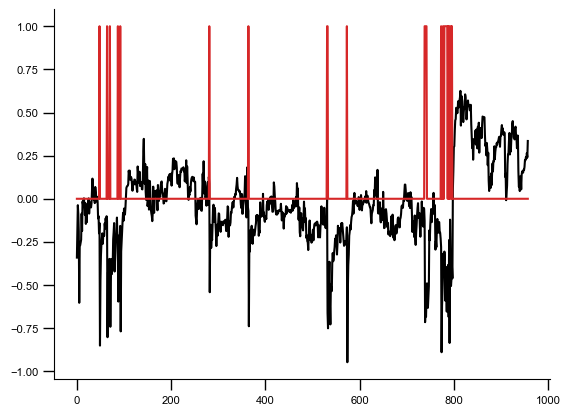

In [47]:
plt.plot(trials.engagement)
plt.plot(trials.choice == 0)

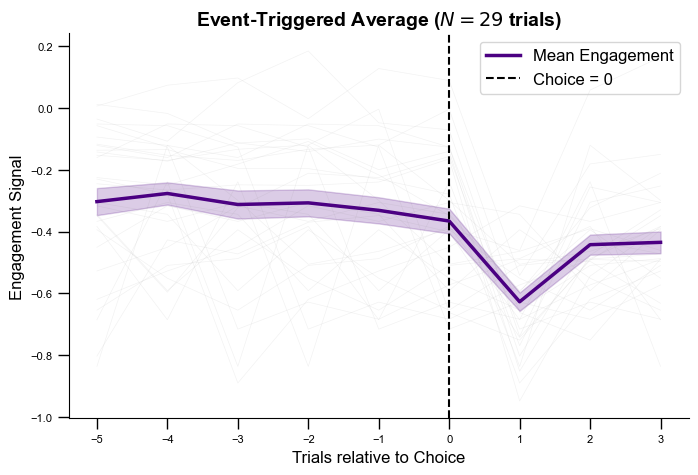

In [ ]:
engagement_signal = engagement_signal[mask.values]  # atleast we get the same masks

stimulus_data, region_names_stim = load_widefield_epoch(
    one, session_id, trials, config["hemisphere"], epoch="stim"
)
choice_data, region_names_choice = load_widefield_epoch(
    one, session_id, trials, config["hemisphere"], epoch="choice"
)

# everything is staged now.
assert region_names_stim == region_names_choice

In [19]:
high_mask, low_mask = get_high_low_masks(engagement_signal)

In [ ]:
stimulus_intrinsic_dimensions = get_intrinsic_dimensions(stimulus_data, high_mask, low_mask)
choice_intrinsic_dimensions = get_intrinsic_dimensions(choice_data, high_mask, low_mask)

In [18]:
ridge_regression_dict = {}
for frameidx in [0, 1]:  # we have two stim frames
    for frameidy in [0, 1]:  # we have two choice frames
        # cpa -> cross prediction array
        all_cpa_high = compute_regionwise_r2(
            stimulus_data, choice_data, frameidx, frameidy, high_mask
        )
        all_cpa_low = compute_regionwise_r2(
            stimulus_data, choice_data, frameidx, frameidy, low_mask
        )
        ridge_regression_dict[(frameidx, frameidy)] = (all_cpa_high, all_cpa_low)

In [20]:
ridge_regression_dict_scaled = {}
for frameidx in [0, 1]:  # we have two stim frames
    for frameidy in [0, 1]:  # we have two choice frames
        # cpa -> cross predict_scaledion array
        all_cpa_high = compute_regionwise_r2(
            stimulus_data, choice_data, frameidx, frameidy, high_mask
        )
        all_cpa_low = compute_regionwise_r2(
            stimulus_data, choice_data, frameidx, frameidy, low_mask
        )
        ridge_regression_dict_scaled[(frameidx, frameidy)] = (all_cpa_high, all_cpa_low)

In [41]:
import seaborn as sns

In [8]:
for fx in [0]:
    print(fx)

0


In [16]:
cross_array_prediction_high, cross_array_prediction_low = ridge_regression_dict_scaled[(0, 1)]

NameError: name 'ridge_regression_dict_scaled' is not defined

In [76]:
def plot_filtered_mi(r2_high, r2_low, labels, threshold=0.10):

    high = np.clip(r2_high, 0, None)
    low = np.clip(r2_low, 0, None)
    labels = [x[0] for x in labels]
    denom = high + low
    mi = np.divide(high - low, denom, out=np.zeros_like(denom), where=denom != 0)

    quality_mask = (high > threshold) | (low > threshold)
    filtered_mi = np.where(quality_mask, mi, np.nan)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        filtered_mi,
        cmap="viridis",
        center=0,
        vmin=-1,
        vmax=1,
        cbar_kws={"label": "Modulation Index"},
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.title(f"Inter-areal Modulation (R² > {threshold})")
    plt.show()

    return filtered_mi[quality_mask]

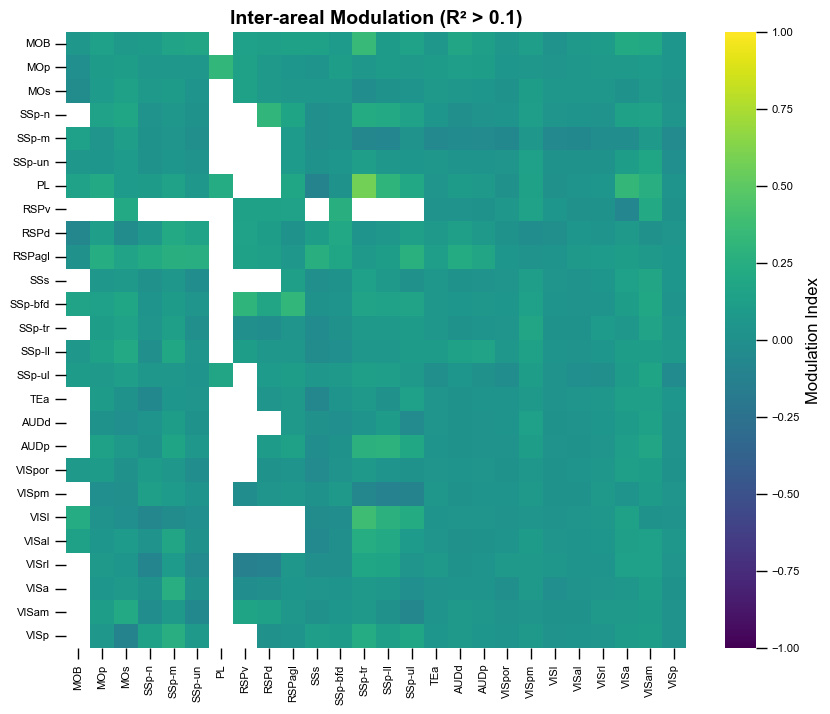

In [77]:
filtered = plot_filtered_mi(all_cpa_high, all_cpa_low, region_names_choice)

In [81]:
from scipy.stats import wilcoxon


def run_significance_tests(r2_high, r2_low, r2_threshold=0.01):
    """
    Performs dual-level significance testing (MI and Raw R2)
    on region pairs passing a baseline quality threshold.
    """

    n = r2_high.shape[0]
    off_diagonal_mask = ~np.eye(n, dtype=bool)

    high_flat = r2_high[off_diagonal_mask]
    low_flat = r2_low[off_diagonal_mask]

    quality_mask = (high_flat >= r2_threshold) | (low_flat >= r2_threshold)

    high_clean = np.clip(high_flat[quality_mask], 0, None)
    low_clean = np.clip(low_flat[quality_mask], 0, None)

    if len(high_clean) == 0:
        print("No region pairs passed the R2 threshold.")
        return None

    denom = high_clean + low_clean
    mi_clean = np.divide(high_clean - low_clean, denom, out=np.zeros_like(denom), where=denom != 0)

    mi_stat, mi_p = wilcoxon(mi_clean)

    raw_stat, raw_p = wilcoxon(high_clean, low_clean, alternative="greater")

    print(f"--- Statistical Report (N={len(high_clean)} pairs) ---")
    print(f"Threshold used: R² > {r2_threshold}")
    print(f"\n1. MODULATION INDEX (Relative Shift)")
    print(f"   Median MI: {np.median(mi_clean):.4f}")
    print(f"   p-value:   {mi_p:.2e} ({'Significant' if mi_p < 0.05 else 'NS'})")

    print(f"\n2. RAW R² (Absolute Shift)")
    print(f"   Mean Engaged:    {np.mean(high_clean):.4f}")
    print(f"   Mean Disengaged: {np.mean(low_clean):.4f}")
    print(f"   p-value (one-sided 'greater'): {raw_p:.2e}")

    return {
        "mi_p": mi_p,
        "raw_p": raw_p,
        "mi_data": mi_clean,
        "high_data": high_clean,
        "low_data": low_clean,
    }

In [83]:
vals = run_significance_tests(
    cross_array_prediction_high, cross_array_prediction_low, r2_threshold=0.1
)

--- Statistical Report (N=536 pairs) ---
Threshold used: R² > 0.1

1. MODULATION INDEX (Relative Shift)
   Median MI: 0.0349
   p-value:   3.04e-22 (Significant)

2. RAW R² (Absolute Shift)
   Mean Engaged:    0.3313
   Mean Disengaged: 0.3097
   p-value (one-sided 'greater'): 8.19e-29


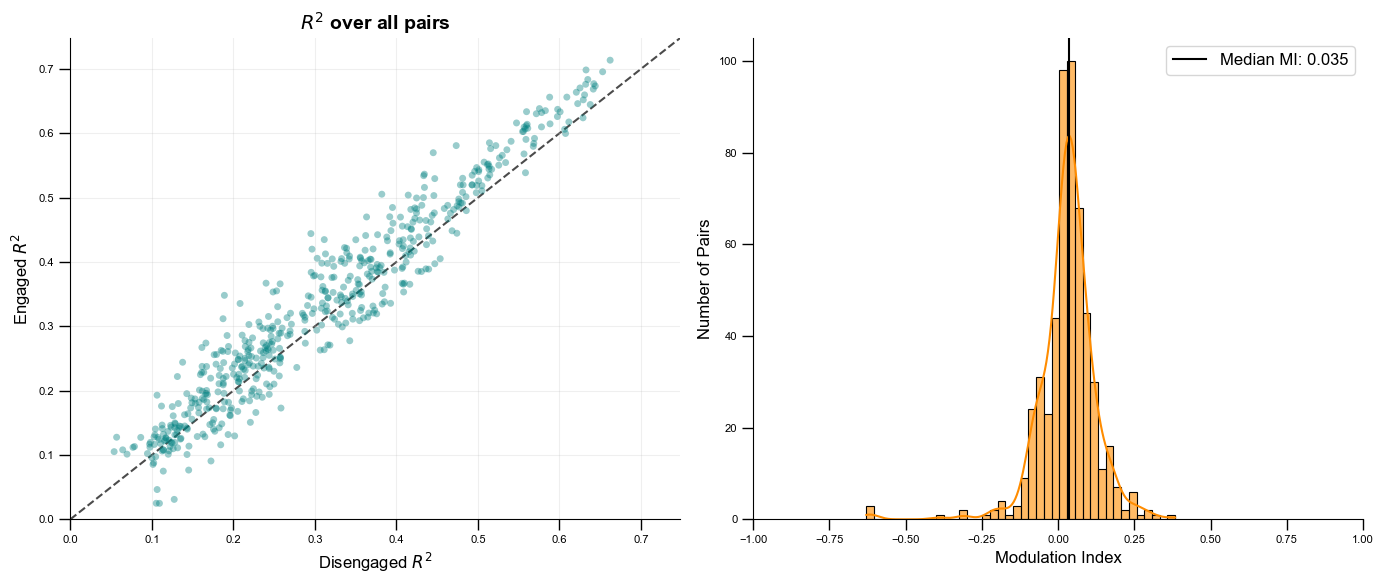

In [102]:
def plot_engagement_results(r2_high, r2_low, r2_threshold=0.01):
    """
    Plots the Unity Scatter and MI Histogram for inter-areal communication.
    """
    # 1. Pre-process (Remove diagonal and apply threshold)
    n = r2_high.shape[0]
    mask = ~np.eye(n, dtype=bool)

    high_flat = r2_high[mask]
    low_flat = r2_low[mask]

    q_mask = (high_flat > r2_threshold) | (low_flat > r2_threshold)
    h_clean = high_flat[q_mask]
    l_clean = low_flat[q_mask]

    denom = h_clean + l_clean
    mi = np.divide(h_clean - l_clean, denom, out=np.zeros_like(denom), where=denom != 0)

    # 2. Setup Figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    ax1.scatter(l_clean, h_clean, alpha=0.4, s=25, color="teal", edgecolor="none")

    lims = [0, max(ax1.get_xlim()[1], ax1.get_ylim()[1])]
    ax1.plot(lims, lims, "k--", alpha=0.7, zorder=0)

    ax1.set_title(f"$R^2$ over all pairs", fontsize=14)
    ax1.set_xlabel("Disengaged $R^2$", fontsize=12)
    ax1.set_ylabel("Engaged $R^2$", fontsize=12)
    ax1.set_xlim(lims)
    ax1.set_ylim(lims)
    ax1.grid(True, alpha=0.2)

    sns.histplot(mi, bins=40, kde=True, ax=ax2, color="darkorange", alpha=0.6)
    ax2.axvline(
        np.median(mi),
        color="k",
        linestyle="-",
        label=f"Median MI: {np.median(mi):.3f}",
    )

    ax2.set_title("", fontsize=14)
    ax2.set_xlabel("Modulation Index", fontsize=12)
    ax2.set_ylabel("Number of Pairs", fontsize=12)
    ax2.set_xlim([-1, 1])  # MI is naturally bounded here
    ax2.legend()

    plt.tight_layout()
    plt.show()


# Run the plot using your result matrices
plot_engagement_results(cross_array_prediction_high, cross_array_prediction_low, r2_threshold=0.1)

In [ ]:
reduced_rank_dict = {}

for frameidx in range(0, 2):
    for frameidy in range(0, 2):
        key = (frameidx, frameidy)
        if key in reduced_rank_dict.keys():
            print("foundkeey")
            continue
        reduced_rank_high = compute_reduced_rank_pairs(
            stimulus_data, choice_data, frameidx, frameidy, high_mask
        )
        reduced_rank_low = compute_reduced_rank_pairs(
            stimulus_data, choice_data, frameidx, frameidy, low_mask
        )
        reduced_rank_dict[(frameidx, frameidy)] = (reduced_rank_high, reduced_rank_low)

In [30]:
storage_dict = {}
storage_dict["ridge_regression_dict"] = ridge_regression_dict
storage_dict["reduced_rank_dict"] = reduced_rank_dict
storage_dict["stimulus_intrinsic_dimensions"] = stimulus_intrinsic_dimensions
storage_dict["choice_intrinsic_dimensions"] = choice_intrinsic_dimensions
storage_dict["regions"] = region_names_stim

In [31]:
filename = f"../data/{session_id}_communication_subspaces.pkl"

In [33]:
with open(filename, "wb") as f:
    pkl.dump(storage_dict, f)

In [43]:
high, low = storage_dict["ridge_regression_dict"][(0, 0)]

In [49]:
from communication_subspace.ibl_communication.utils import compute_modulation_indices

In [62]:
modulation_indices = compute_modulation_indices(high, low)

In [52]:
import seaborn as sns

In [76]:
# dashboard?
import ipywidgets as widgets
from IPython.display import display

In [77]:
def plot_subspace_curve(source_idx, target_idx, subspace_dict_main, region_names):

    # 1. Extract the specific dictionary for this pair
    pair_data = subspace_dict_main.get((source_idx, target_idx))

    if pair_data is None:
        print("Data for this pair does not exist or failed to converge.")
        return

    optimal_rank = pair_data["optimal_rank"]
    mean_r2 = pair_data["mean_r2"]
    sem_r2 = pair_data["sem_r2"]

    # Generate the X-axis (ranks tested)
    ranks = np.arange(1, len(mean_r2) + 1)

    # 2. Build the Plot
    plt.figure(figsize=(8, 5))

    # Plot the main curve with error bands
    plt.errorbar(
        ranks,
        mean_r2,
        yerr=sem_r2,
        fmt="-o",
        color="royalblue",
        capsize=4,
        linewidth=2,
        label="Mean CV $R^2 \pm 1$ SEM",
    )

    # Mark the optimal rank
    optimal_idx = optimal_rank - 1  # 0-indexed
    plt.plot(
        optimal_rank,
        mean_r2[optimal_idx],
        "D",
        color="red",
        markersize=10,
        label=f"Optimal Rank: {optimal_rank}",
    )

    # Formatting
    source_name = region_names[source_idx]
    target_name = region_names[target_idx]

    plt.title(f"Communication Subspace: {source_name} $\\rightarrow$ {target_name}", fontsize=14)
    plt.xlabel("Number of Predictive Dimensions (Rank)", fontsize=12)
    plt.ylabel("Cross-Validated $R^2$", fontsize=12)
    plt.xticks(ranks)
    plt.grid(True, alpha=0.3)
    plt.legend(loc="lower right")

    # Ensure the Y-axis starts at 0, but allow it to grow dynamically
    plt.ylim(bottom=0, top=max(mean_r2) + max(sem_r2) + 0.05)

    plt.show()


def create_interactive_dashboard(subspace_dict_main, region_names):

    # Create dropdowns for Source and Target
    source_dropdown = widgets.Dropdown(
        options=[(name, idx) for idx, name in enumerate(region_names)], description="Source (X):"
    )

    target_dropdown = widgets.Dropdown(
        options=[(name, idx) for idx, name in enumerate(region_names)], description="Target (Y):"
    )

    # Use ipywidgets interact to link the dropdowns to the plotting function
    ui = widgets.HBox([source_dropdown, target_dropdown])

    out = widgets.interactive_output(
        plot_subspace_curve,
        {
            "source_idx": source_dropdown,
            "target_idx": target_dropdown,
            "subspace_dict_main": widgets.fixed(subspace_dict_main),
            "region_names": widgets.fixed(region_names),
        },
    )

    display(ui, out)

In [84]:
reduced_rank_high, reduced_rank_low = storage_dict["reduced_rank_dict"][(0, 0)]

In [88]:
cvr2_reducedridge = np.zeros((26, 26))
for k in reduced_rank_high.keys():
    idx, idy = k
    cvr2_reducedridge[idx, idy] = reduced_rank_high[k]["cv_r2"]

<Axes: >

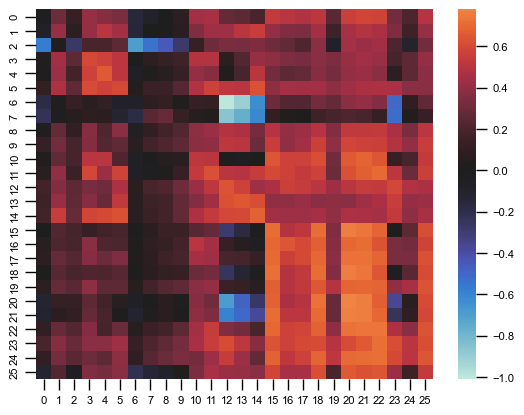

In [90]:
sns.heatmap(cvr2_reducedridge, center=0)

In [99]:
high, low = ridge_regression_dict[1, 0]
high_scaled, low_scaled = ridge_regression_dict_scaled[1, 0]

In [106]:
delta = low_scaled - low

### Old code

In [6]:
# try the other one

session_id = sessions[0]
trials, mask = load_trials_and_mask(
    one,
    session_id,
    exclude_nochoice=True,
    exclude_unbiased=False,
)
trials = trials[mask]

hemisphere = ("left", "right")
align_event = "stimOn_times"
min_rt = 0.08
max_rt = None

align_times = trials[align_event].values

In [ ]:
data_epoch, actual_regions = prepare_widefield(
    one,
    session_id,
    hemisphere,
    regions="single_regions",
    align_times=align_times,
    frame_window=(-1, 0),
    functional_channel=470,
    stage_only=False,
)

In [11]:
import warnings

warnings.filterwarnings("ignore")

In [75]:
# check this for single frame, contrast fa and pca dimensions

pca_dimensions = []
fa_dimensions = []
for neural_data_frames in data_epoch:
    # first choose the proper frame
    neural_data = neural_data_frames[:, 1, :]  # 0th
    # now in trials x neurons
    # if voxels less than 10, maybe we don't bother (?)
    pca_components, _ = compute_intrinsic_dimensionality_pca(neural_data)
    fa_components, _ = compute_intrinsic_dimensionality_fa(neural_data)
    pca_dimensions.append(pca_components)
    fa_dimensions.append(fa_components)

In [44]:
# load engagement, do median split
# then estimate dimensionality
session_id

UUID('f7d46a15-9498-40dc-90da-fb977ce844be')

In [50]:
alleidpmotivation = pkl.load(
    open("../../public_hybrid_rnn/session_data/wifimicemotivation.pkl", "rb")
)

In [54]:
len(alleidpmotivation.keys())

50

In [56]:
session_id = str(session_id)

In [63]:
motivation_scalar = alleidpmotivation[session_id]

In [65]:
subsetmotivationscalar = motivation_scalar[mask.values]

In [70]:
median_val = np.median(subsetmotivationscalar)

In [71]:
high_mask = subsetmotivationscalar >= median_val
low_mask = subsetmotivationscalar < median_val

In [ ]:
# run the pca, fa

# check this for single frame, contrast fa and pca dimensions

pca_dimensions_engagement = []
fa_dimensions_engagement = []
for neural_data_frames in data_epoch:
    # first choose the proper frame
    neural_data = neural_data_frames[:, 1, :]  # 0th
    # now in trials x neurons
    # if voxels less than 10, maybe we don't bother (?)
    pca_components_high, _ = compute_intrinsic_dimensionality_pca(neural_data[high_mask, :])
    fa_components_high, _ = compute_intrinsic_dimensionality_fa(neural_data[high_mask, :])

    pca_components_low, _ = compute_intrinsic_dimensionality_pca(neural_data[low_mask, :])
    fa_components_low, _ = compute_intrinsic_dimensionality_fa(neural_data[low_mask, :])

    pca_dimensions_engagement.append([pca_components_high, pca_components_low])
    fa_dimensions_engagement.append([fa_components_high, fa_components_low])

In [79]:
alphas = np.logspace(-3, 2, 5)

In [80]:
alphas

array([1.00000000e-03, 1.77827941e-02, 3.16227766e-01, 5.62341325e+00,
       1.00000000e+02])

In [81]:
from communication_subspace.ibl_communication.crossvalidated_ridge import ridgeregression

In [125]:
data_epoch_reduced = []
regions = []
for idx in range(len(data_epoch)):
    if data_epoch[idx].shape[-1] < 10:
        continue
    else:
        data_epoch_reduced.append(data_epoch[idx])
        regions.append(actual_regions[idx])

In [126]:
len(data_epoch_reduced)

31

In [127]:
def compute_regionwiser2(data, frameidx, trialmask=None):
    # data is nregions x ntrials x nframes x nsessions
    n_regions = len(data)
    cross_array_predictions = np.zeros((n_regions, n_regions))
    if trialmask is None:
        trialmask = np.ones(data[0].shape[0], dtype=bool)  # all is valid
    for idx in range(n_regions):
        region_x = data[idx][trialmask, frameidx, :]
        for idy in range(n_regions):
            region_y = data[idy][trialmask, frameidx, :]

            cross_array_predictions[idx, idy] = ridgeregression(region_x, region_y)
    return cross_array_predictions

In [129]:
crossarraypreds_high = compute_regionwiser2(data_epoch_reduced, 1, high_mask)

In [128]:
crossarraypreds_low = compute_regionwiser2(data_epoch_reduced, 1, low_mask)

In [130]:
modulation_indices = np.zeros_like(crossarraypreds_high)
for idx in range(crossarraypreds_high.shape[0]):
    for idy in range(crossarraypreds_high.shape[1]):
        modulation_indices[idx, idy] = (
            crossarraypreds_high[idx, idy] - crossarraypreds_low[idx, idy]
        ) / (crossarraypreds_high[idx, idy] + crossarraypreds_low[idx, idy])

<Axes: >

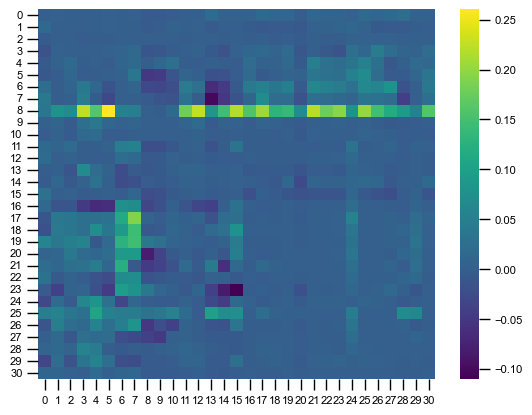

In [131]:
sns.heatmap(modulation_indices, cmap="viridis")

In [137]:
# okay, now what?

In [ ]:
# data_epoch_reduced

In [143]:
from communication_subspace.ibl_communication.crossvalidated_rrr import optimize_rrr_rank

In [144]:
# optimal_rank, final_r2, mean_r2, sem_r2

In [146]:
X = data_epoch_reduced[8][:, 1, :]
Y = data_epoch_reduced[11][:, 1, :]

In [193]:
from communication_subspace.ibl_communication.utils import *

In [185]:
d_choice, r = load_widefield_epoch(one, session_id, trials, hemisphere, epoch="choice")
d_stim, r = load_widefield_epoch(one, session_id, trials, hemisphere, epoch="stim")

In [167]:
from communication_subspace.ibl_communication.intrinsic_dimensionality import (
    compute_intrinsic_dimensionality,
)

In [209]:
all_cpa_high = compute_regionwise_r2(d_stim, d_choice, 0, 1, high_mask)
all_cpa_low = compute_regionwise_r2(d_stim, d_choice, 0, 1, low_mask)

In [194]:
modulation_indices = compute_modulation_indices(all_cpa_high, all_cpa_low)

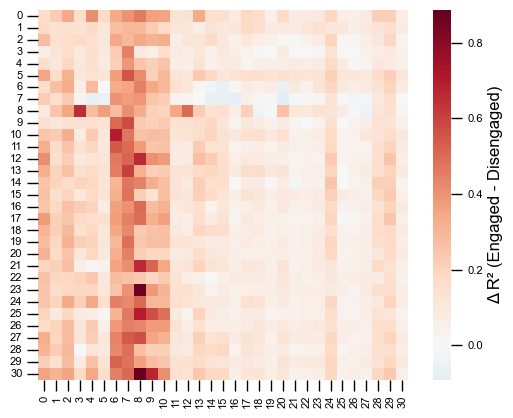

In [203]:
ax = sns.heatmap(
    modulation_indices,
    cmap="RdBu_r",  # Red-Blue diverging colormap (reversed so Red is positive)
    center=0,  # Anchor white at exactly 0
    square=True,  # Force perfect squares
    annot=False,  # Do NOT print numbers inside 1024 cells
    xticklabels=True,  # Show all 32 regions
    yticklabels=True,
    cbar_kws={"label": "Δ R² (Engaged - Disengaged)"},
)

In [2]:
import pickle as pkl

w = pkl.load(open("../data/processed/wifi_trials_df_all.pkl", "rb"))

In [3]:
w["12046ccd-b737-4c01-bc70-400f3b69291b"]

,goCueTrigger_times,quiescencePeriod,stimOff_times,goCue_times,response_times,choice,stimOn_times,contrastLeft,contrastRight,probabilityLeft,...,feedbackType,rewardVolume,firstMovement_times,intervals_0,intervals_1,prior,prediction_error_left,prediction_error_right,sign_cont,motivation
0,59.681511,0.691901,61.498013,59.682229,59.944009,1.0,59.681379,0.25,NaN,0.5,...,1.0,2.0,59.837402,58.905317,61.997997,0.500000,0.173007,0.826993,0.2500,-0.340870
1,63.333013,0.546522,65.081059,63.333904,63.531518,1.0,63.332866,0.25,NaN,0.5,...,1.0,2.0,63.450402,62.450792,65.581169,0.602422,0.140433,0.859567,0.2500,0.344742
2,66.466274,0.435289,69.414397,66.467134,66.855473,1.0,66.466096,NaN,0.0625,0.5,...,-1.0,0.0,66.577402,65.967475,69.914466,0.683864,0.434815,0.565185,-0.0625,0.176407
3,71.016261,0.645150,72.782494,71.017120,71.208660,1.0,71.016082,1.00,NaN,0.5,...,1.0,2.0,71.117402,70.323563,73.282554,0.748622,0.093277,0.906723,1.0000,-0.091420
4,74.431156,0.693158,76.247541,74.432040,74.675358,-1.0,74.431002,NaN,0.2500,0.5,...,1.0,2.0,74.527402,73.666550,76.747577,0.800116,0.629728,0.370272,-0.2500,0.040846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1071,5009.097257,0.474693,5010.980542,5009.097923,5009.446160,-1.0,5009.097168,NaN,0.2500,0.2,...,1.0,2.0,5009.205402,5008.081046,5011.480684,0.662233,0.758253,0.241747,-0.2500,-0.281845
1072,5013.331998,0.412474,5015.263848,5013.332896,5013.724101,-1.0,5013.331763,NaN,0.2500,0.2,...,1.0,2.0,5013.445402,5012.852494,5015.763919,0.526578,0.834454,0.165546,-0.2500,-0.268598
1073,5017.615528,0.423164,5019.397058,5017.616202,5017.842129,-1.0,5017.615352,NaN,1.0000,0.2,...,1.0,2.0,5017.721402,5017.138726,5019.897140,0.418712,0.929882,0.070118,-1.0000,-0.239548
1074,5021.915440,0.443330,5024.731696,5021.916122,5022.152340,1.0,5021.915272,NaN,0.2500,0.2,...,-1.0,0.0,5022.021402,5021.399942,5025.231831,0.332941,0.895967,0.104033,-0.2500,-0.276853
